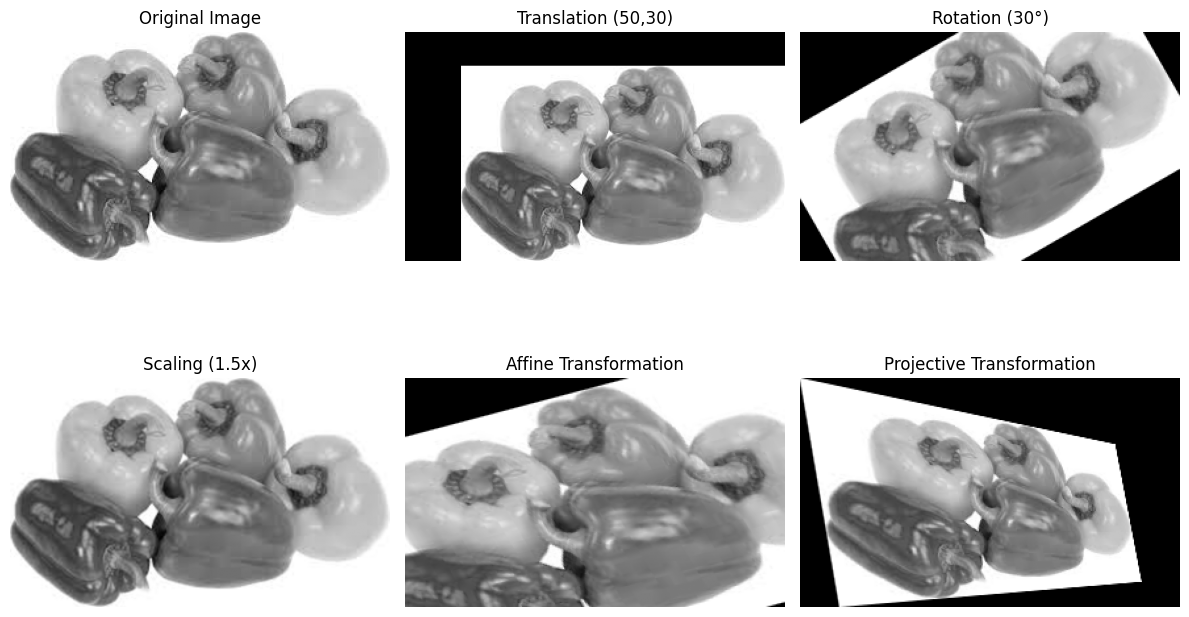

In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Read an in-built grayscale image

img = cv2.imread(cv2.samples.findFile('peppers.jpeg'), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image not found. Replace 'lena.jpg' with your own image path (e.g., 'cameraman.tif').")

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Translation
tx, ty = 50, 30  # shift by (50, 30)
M_translate = np.float32([[1, 0, tx],
                          [0, 1, ty]])
translated = cv2.warpAffine(img, M_translate, (img.shape[1] + tx, img.shape[0] + ty))
plt.subplot(2, 3, 2)
plt.imshow(translated, cmap='gray')
plt.title(f'Translation ({tx},{ty})')
plt.axis('off')

# Rotation
angle = 30
M_rotate = cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), angle, 1)
rotated = cv2.warpAffine(img, M_rotate, (img.shape[1], img.shape[0]))
plt.subplot(2, 3, 3)
plt.imshow(rotated, cmap='gray')
plt.title(f'Rotation ({angle}°)')
plt.axis('off')

# Scaling 
scale_factor = 1.5
scaled = cv2.resize(img, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)
plt.subplot(2, 3, 4)
plt.imshow(scaled, cmap='gray')
plt.title(f'Scaling ({scale_factor}x)')
plt.axis('off')

# Affine Transformation (Shearing)
rows, cols = img.shape
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])
M_affine = cv2.getAffineTransform(pts1, pts2)
affine_img = cv2.warpAffine(img, M_affine, (cols, rows))
plt.subplot(2, 3, 5)
plt.imshow(affine_img, cmap='gray')
plt.title('Affine Transformation')
plt.axis('off')

#Projective Transformation 
h, w = img.shape
input_pts = np.float32([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]])
output_pts = np.float32([[0, 0], [w-50, 50], [w-30, h-20], [30, h-1]])
M_proj = cv2.getPerspectiveTransform(input_pts, output_pts)
projective_img = cv2.warpPerspective(img, M_proj, (w, h))
plt.subplot(2, 3, 6)
plt.imshow(projective_img, cmap='gray')
plt.title('Projective Transformation')
plt.axis('off')

plt.tight_layout()
plt.show()
